### Imports e Preparação Inicial

In [1]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#importacao do dataset
path_dataset = 'healthcare_dataset.csv'

df = pd.read_csv(path_dataset)

In [3]:
#exploração básica dos dados

print('Info:')
print(df.info())
print('-'*70)

print('\n')
print('Describe:')
print(df.describe())
print('-'*70)

print('\n')
print("Head dos dados:")
print(df.head())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usag

In [4]:
#Converter colunas de datas
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

#Conferir novos dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                55500 non-null  object        
 1   Age                 55500 non-null  int64         
 2   Gender              55500 non-null  object        
 3   Blood Type          55500 non-null  object        
 4   Medical Condition   55500 non-null  object        
 5   Date of Admission   55500 non-null  datetime64[ns]
 6   Doctor              55500 non-null  object        
 7   Hospital            55500 non-null  object        
 8   Insurance Provider  55500 non-null  object        
 9   Billing Amount      55500 non-null  float64       
 10  Room Number         55500 non-null  int64         
 11  Admission Type      55500 non-null  object        
 12  Discharge Date      55500 non-null  datetime64[ns]
 13  Medication          55500 non-null  object    

In [5]:
#Criar Coluna tempo de internação
df['LOS'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

df['LOS']

0         2
1         6
2        15
3        30
4        20
         ..
55495    30
55496     9
55497    28
55498     6
55499    27
Name: LOS, Length: 55500, dtype: int64

### Limpeza e preparação dos dados

In [6]:
#Verificar valores ausentes
df.isna().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
LOS                   0
dtype: int64

In [7]:
#Sem valores ausentes encontrados

In [8]:
#Verificar registros duplicados
df.duplicated().sum()

np.int64(534)

In [9]:
#Remover duplicados encontrados e criar novo df tratado
df_clean = df.drop_duplicates().copy()

In [10]:
#Padronizar Nomes com as primeiras letras maiúsculas
df_clean['Name'] = df_clean['Name'].str.title()

In [11]:
#Conferir padroes de colunas categoricas (identificar falta de padrões)
colunas_categoricas = ['Gender','Blood Type','Medical Condition','Admission Type','Test Results']

for col in colunas_categoricas:
    print(f'Análise de valores únicos da coluna {col}:')
    print(df_clean[col].value_counts())
    print('-'*50,'\n')

Análise de valores únicos da coluna Gender:
Gender
Male      27496
Female    27470
Name: count, dtype: int64
-------------------------------------------------- 

Análise de valores únicos da coluna Blood Type:
Blood Type
A-     6898
A+     6896
B+     6885
AB+    6882
AB-    6874
B-     6872
O+     6855
O-     6804
Name: count, dtype: int64
-------------------------------------------------- 

Análise de valores únicos da coluna Medical Condition:
Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64
-------------------------------------------------- 

Análise de valores únicos da coluna Admission Type:
Admission Type
Elective     18473
Urgent       18391
Emergency    18102
Name: count, dtype: int64
-------------------------------------------------- 

Análise de valores únicos da coluna Test Results:
Test Results
Abnormal        18437
Normal          18331
Inconclusive    

In [12]:
#Verificar outliers

colunas_num = ['Age','LOS','Billing Amount']

for col in colunas_num:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3-Q1
    LI = Q1 - 1.5 * Q1
    LS = Q3 + 1.5 * Q3

    print(f'Dados referencia da coluna {col}:')
    print(f'Q1: {Q1}')
    print(f'Q3: {Q3}')
    print(f'IQR: {IQR}')
    print(f'Limite inferior: {LI}')
    print(f'Limite Superior: {LS}')
    print('-'*50,'\n')


Dados referencia da coluna Age:
Q1: 35.0
Q3: 68.0
IQR: 33.0
Limite inferior: -17.5
Limite Superior: 170.0
-------------------------------------------------- 

Dados referencia da coluna LOS:
Q1: 8.0
Q3: 23.0
IQR: 15.0
Limite inferior: -4.0
Limite Superior: 57.5
-------------------------------------------------- 

Dados referencia da coluna Billing Amount:
Q1: 13243.71864076912
Q3: 37819.85815919015
IQR: 24576.139518421034
Limite inferior: -6621.859320384561
Limite Superior: 94549.64539797537
-------------------------------------------------- 



In [13]:
#Verificar outliers - tratar limites negativos encontrados anteriormente

colunas_num = ['Age','LOS','Billing Amount']

dic_dados_outliers = {}

for col in colunas_num:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3-Q1
    LI = max(0, Q1 - 1.5 * Q1) #tratar valores negativos, que não fazem sentido para as métricas.
    LS = Q3 + 1.5 * Q3

    print(f'Dados referencia da coluna {col}:')
    print(f'Q1: {Q1}')
    print(f'Q3: {Q3}')
    print(f'IQR: {IQR}')
    print(f'Limite inferior: {LI}')
    print(f'Limite Superior: {LS}')
    print('-'*50,'\n')

    #definir dicionario para armazenar os dados de cada coluna
    dic_dados_outliers[col] = {
        'Q1':Q1,
        'Q3':Q3,
        'IQR':IQR,
        'LI':LI,
        'LS':LS
    }


Dados referencia da coluna Age:
Q1: 35.0
Q3: 68.0
IQR: 33.0
Limite inferior: 0
Limite Superior: 170.0
-------------------------------------------------- 

Dados referencia da coluna LOS:
Q1: 8.0
Q3: 23.0
IQR: 15.0
Limite inferior: 0
Limite Superior: 57.5
-------------------------------------------------- 

Dados referencia da coluna Billing Amount:
Q1: 13243.71864076912
Q3: 37819.85815919015
IQR: 24576.139518421034
Limite inferior: 0
Limite Superior: 94549.64539797537
-------------------------------------------------- 



In [14]:
#Quantificar outliers nas colunas
for k,v in dic_dados_outliers.items():
    Q1 = v.get('Q1')
    Q3 = v.get('Q3')
    IQR = v.get('IQR')
    LI = v.get('LI')
    LS = v.get('LS')

    qtd_abaixo = (df_clean[k] < LI).sum()
    qtd_acima = (df_clean[k] > LS).sum()

    print(f"A coluna {k} apresenta {qtd_abaixo} valores abaixo de Q1 e {qtd_acima} valores acima de Q3")

A coluna Age apresenta 0 valores abaixo de Q1 e 0 valores acima de Q3
A coluna LOS apresenta 0 valores abaixo de Q1 e 0 valores acima de Q3
A coluna Billing Amount apresenta 106 valores abaixo de Q1 e 0 valores acima de Q3


In [15]:
#Outliers: não encontrados no passo anterior, prosseguir análise

### Análise Exploratória e Estatísticas Descritivas

In [16]:
#Obter média, mediana, desvio padrão de variáveis numéricas

#Exibir os dados para cada coluna:
for col in colunas_num:
    print(f'Dados estatísticos da coluna {col}:')
    print(f'Média: {df_clean[col].mean():.2f}')
    print(f'Mediana: {df_clean[col].quantile(0.5):.2f}')
    print(f'Desvio Padrão: {df_clean[col].std():.2f}')
    print(f'Mínimo: {df_clean[col].min():.2f}')
    print(f'Máximo: {df_clean[col].max():.2f}')
    print('-'*50,'\n')

Dados estatísticos da coluna Age:
Média: 51.54
Mediana: 52.00
Desvio Padrão: 19.61
Mínimo: 13.00
Máximo: 89.00
-------------------------------------------------- 

Dados estatísticos da coluna LOS:
Média: 15.50
Mediana: 15.00
Desvio Padrão: 8.66
Mínimo: 1.00
Máximo: 30.00
-------------------------------------------------- 

Dados estatísticos da coluna Billing Amount:
Média: 25544.31
Mediana: 25542.75
Desvio Padrão: 14208.41
Mínimo: -2008.49
Máximo: 52764.28
-------------------------------------------------- 



In [17]:
#Verificar distribuição de frequências para variáveis categóricas
#Já visto anteriormente, mas agora focando na distribuição e não na falta de padrões

for col in colunas_categoricas:
    contagem = df_clean[col].value_counts().sort_values(ascending=False)
    valor_max = contagem.max()
    valor_min = contagem.min()
    categorias_max = contagem[contagem == valor_max].index.tolist()
    categorias_min = contagem[contagem == valor_min].index.tolist()
    
    print(f'Análise de valores únicos da coluna {col}, do maior para o menor:')
    print(contagem,'\n')
    print(f'Maior Frequência Categoria: {valor_max}')
    print(f'Categoria(s) mais frequente(s): {",".join(categorias_max)}')
    print(f'Menor Frequência Categoria: {valor_min}')
    print(f'Categoria(s) menos frequente(s): {",".join(categorias_min)}')
    print('\n')
    print('-'*50,'\n')

Análise de valores únicos da coluna Gender, do maior para o menor:
Gender
Male      27496
Female    27470
Name: count, dtype: int64 

Maior Frequência Categoria: 27496
Categoria(s) mais frequente(s): Male
Menor Frequência Categoria: 27470
Categoria(s) menos frequente(s): Female


-------------------------------------------------- 

Análise de valores únicos da coluna Blood Type, do maior para o menor:
Blood Type
A-     6898
A+     6896
B+     6885
AB+    6882
AB-    6874
B-     6872
O+     6855
O-     6804
Name: count, dtype: int64 

Maior Frequência Categoria: 6898
Categoria(s) mais frequente(s): A-
Menor Frequência Categoria: 6804
Categoria(s) menos frequente(s): O-


-------------------------------------------------- 

Análise de valores únicos da coluna Medical Condition, do maior para o menor:
Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64 

Maior Frequência C

In [18]:
#Criar colunas novas colunas derivadas utilizando funções lambda

#Criar coluna classificatória faixa etária
def classifica_idade(idade):
    match idade:
        case n if n < 3:
            return 'Bebê'
        case n if n < 12:
            return 'Criança'
        case n if n < 19:
            return 'Adolescente'
        case n if n < 60:
            return 'Adulto'
        case _:
            return 'Idoso'
            
df_clean['Faixa Etária'] = df_clean['Age'].map(classifica_idade)

#Criar coluna classificatória de tempo de internação
def classifica_internacao(LOS):
    match LOS:
        case n if n <=2:
            return 'Rápido'
        case n if n <=7:
            return 'Breve'
        case _:
            return 'Demorado'

df_clean['Classificação LOS'] = df_clean['LOS'].map(classifica_internacao)

### Criar views de agrupamentos para entender possíveis correlações

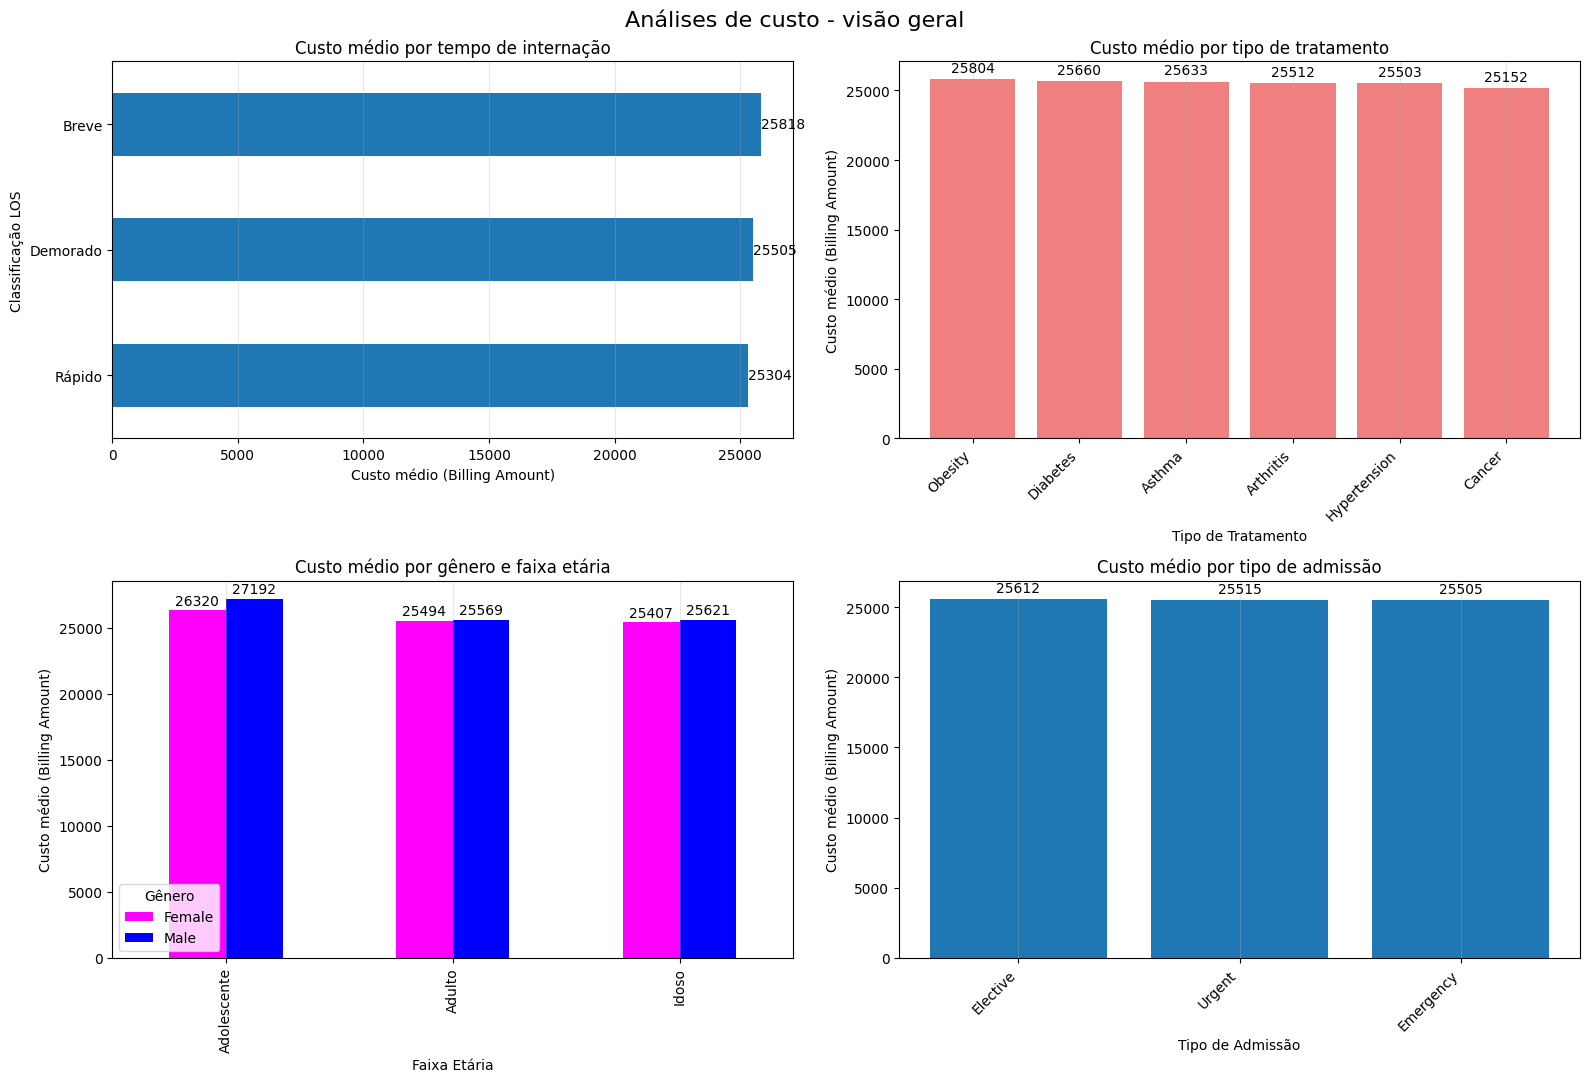

In [19]:
#---------------------Configurações------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 11))  # 2 linhas x 2 colunas


#-----------------------------------------------------------

#Plot 1
# Custo médio de tratamento por tempo de internação

ax = axes[0, 0]

view_1 = (
    df_clean
    .groupby('Classificação LOS')['Billing Amount']
    .mean()
)

#plotagem via plot pandas
view_1.plot(
    kind='barh',
    ax=ax #para incluir no subplot
)

#Rótulos automáticos
ax.bar_label(ax.containers[0], fmt='%.0f')

#Títulos e legendas
ax.set_title('Custo médio por tempo de internação')
ax.set_xlabel('Custo médio (Billing Amount)')
ax.set_ylabel('Classificação LOS')

ax.invert_yaxis()  # coloca maior em cima


#Plot 2
# Custo médio de tratamento por tipo de tratamento
ax = axes[0, 1]

view_2 = (
    df_clean
    .groupby('Medical Condition', as_index=False)['Billing Amount']
    .mean()
    .sort_values('Billing Amount', ascending=False)
)

#Plotagem via pyplot puro
# Cria o gráfico e captura o container de barras
bars = ax.bar(view_2['Medical Condition'], view_2['Billing Amount'], color='lightcoral')

# Adiciona os rótulos automaticamente
ax.bar_label(bars, fmt='%.0f', padding=3)

#Títulos e legendas
ax.set_title('Custo médio por tipo de tratamento')
ax.set_xlabel('Tipo de Tratamento')
ax.set_ylabel('Custo médio (Billing Amount)')

ax.set_xticks(range(len(view_2['Medical Condition'])))
ax.set_xticklabels(view_2['Medical Condition'], rotation=45, ha='right')


#Plot 3
# Custo médio de tratamento por gênero e faixa etária (barras lado a lado via pivot)
ax = axes[1, 0]
view_3 = (
    df_clean
    .groupby(['Gender','Faixa Etária'], as_index=False)['Billing Amount']
    .mean()
)

#reorganizar para agrupar as faixas por gênero
pivot_view = view_3.pivot(index='Faixa Etária', columns='Gender', values='Billing Amount')

#Plotagem via pandas para facilitar
pivot_view.plot(
    kind = 'bar',
    ax = ax, #plotar no subplot correto
    color=['magenta', 'blue'] # cores personalizadas
)

# Rótulos automáticos
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=2)

#Títulos e legendas
ax.set_title('Custo médio por gênero e faixa etária')
ax.set_xlabel('Faixa Etária')
ax.set_ylabel('Custo médio (Billing Amount)')
ax.legend(title='Gênero')


#Plot 4
# Custo médio por tipo de admissão
ax = axes[1,1]

view_4 = (
    df_clean
    .groupby(['Admission Type'], as_index=False)['Billing Amount']
    .mean()
    .sort_values('Billing Amount', ascending=False)
)

#Plotagem via pyplot puro

# Cria o gráfico e captura o container de barras
bars = ax.bar(view_4['Admission Type'],view_4['Billing Amount'])

# Adiciona os rótulos automaticamente
ax.bar_label(bars, fmt='%.0f', padding=3)

#Títulos e legendas
ax.set_title('Custo médio por tipo de admissão')
ax.set_xlabel('Tipo de Admissão')
ax.set_ylabel('Custo médio (Billing Amount)')

ax.set_xticks(range(len(view_4['Admission Type'])))
ax.set_xticklabels(view_4['Admission Type'], rotation=45, ha='right')


# ----------------- FINALIZAÇÃO -----------------
# Ajustes finais comuns
for ax in axes.flatten():
    ax.grid(axis='x', linestyle='-', alpha=0.3)  # grade sutil horizontal
fig.suptitle('Análises de custo - visão geral', fontsize=16)
plt.tight_layout() 
plt.show()

 

Análise geral de custos mostra muito equilíbrio, não identificando valores muito destoantes das médias, qualquer seja o agrupamento utilizado, com exceção da faixa etária adolescente (e o gênero masculino nessa faixa etária).

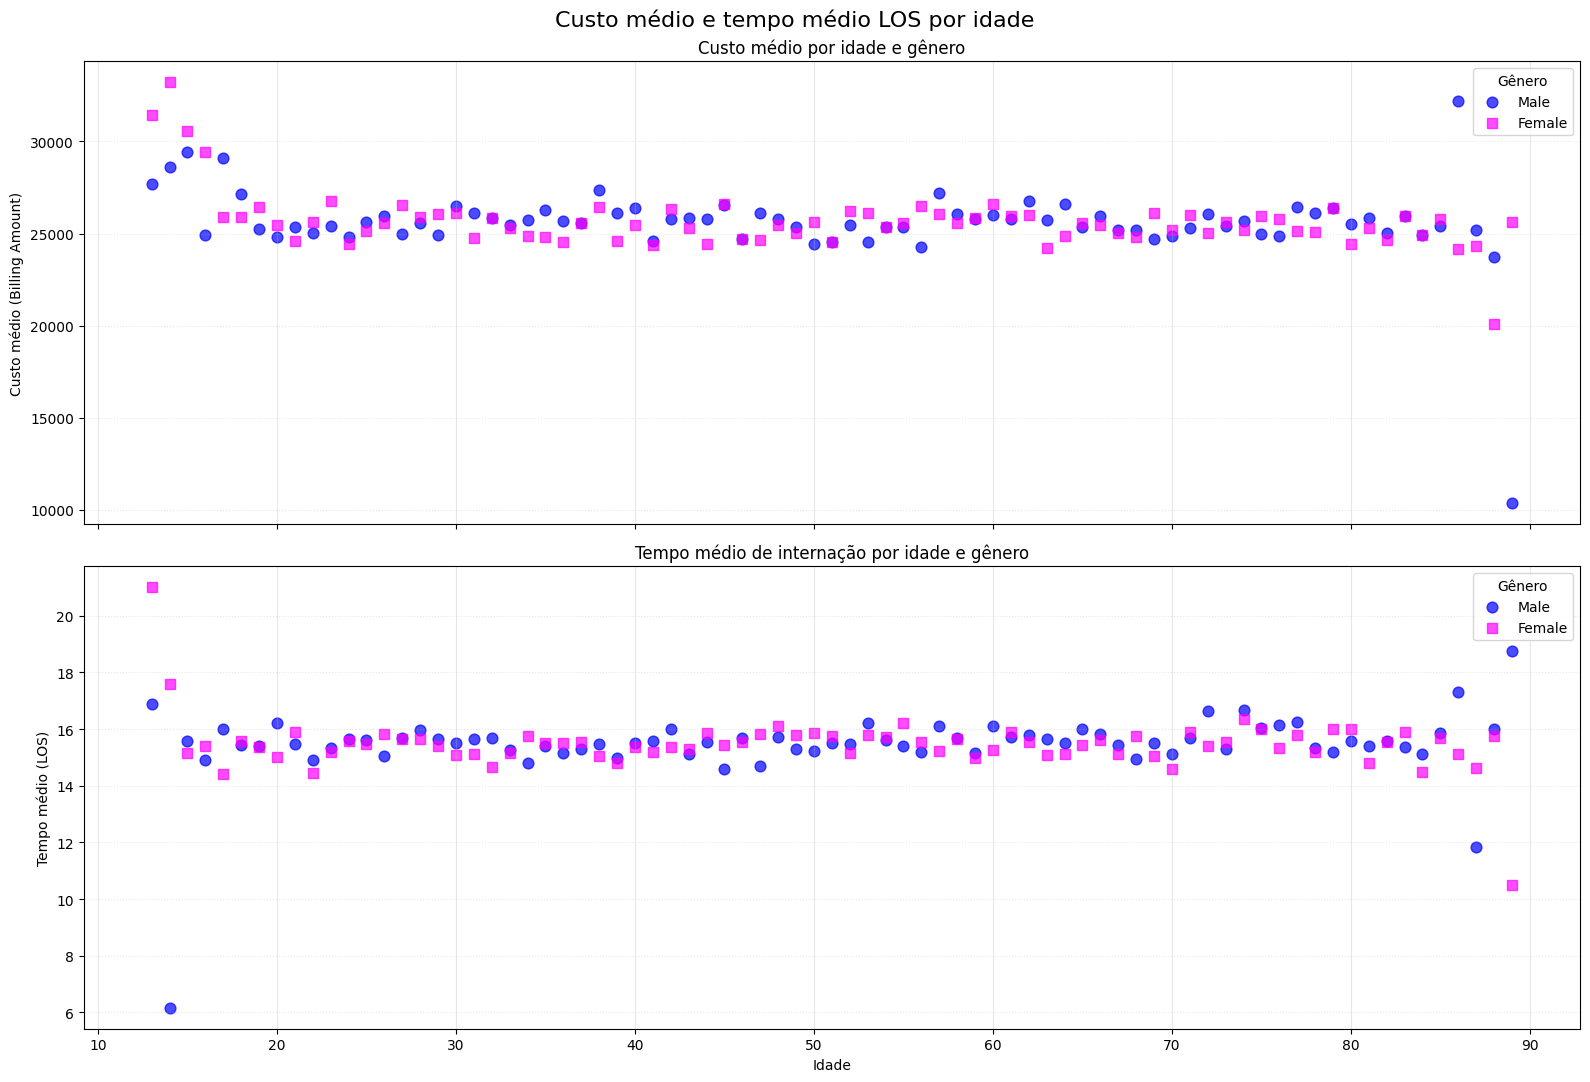

In [20]:
#---------------------Configurações------------------------

fig, axes = plt.subplots(2, figsize=(16, 11),sharex=True)  # 2 linhas x 1 coluna, compartilhando eixo x

# personalizações
cores_genero = {'Male': 'blue', 'Female': 'magenta'}
marcadores = {'Male': 'o', 'Female': 's'}  # círculo para homens, quadrado para mulheres

#-----------------------------------------------------------


#Custo médio e tempo médio de tratamento por idade e gênero

view = (
    df_clean
    .groupby(['Age','Gender'], as_index=False)
    .agg({
        'Billing Amount':'mean',
        'LOS':'mean'
    })
)

#Pivot para separar os generos em colunas
pivot_custo = view.pivot(index = 'Age', columns = 'Gender', values = 'Billing Amount')
pivot_LOS = view.pivot(index = 'Age', columns = 'Gender', values = 'LOS')


#pivot 1 - custo médio - via pyplot raiz
ax = axes[0]

for genero, cor in cores_genero.items():
    ax.scatter(
        pivot_custo.index,      #eixo X (idade)
        pivot_custo[genero],    #eixo Y (custo do genero)
        color=cor,              #assume a cor definida no dicionário
        marker=marcadores[genero],  # marcador diferenciado por gênero
        alpha=0.7,              #transparência do ponto
        label=genero,
        s=60                    #tamanho do marcador
    )

ax.set_title('Custo médio por idade e gênero')
ax.set_ylabel('Custo médio (Billing Amount)')
ax.legend(title='Gênero')
ax.grid(axis='y', linestyle=':', alpha=0.3)


#pivot 2 - tempo médio de internação - via pyplot raiz
ax = axes[1]

for genero, cor in cores_genero.items():
    ax.scatter(
        pivot_LOS.index,
        pivot_LOS[genero],
        color=cor,
        marker=marcadores[genero],  # marcador diferenciado por gênero
        alpha=0.7,
        label=genero,
        s=60
    )

ax.set_title('Tempo médio de internação por idade e gênero')
ax.set_xlabel('Idade')
ax.set_ylabel('Tempo médio (LOS)')
ax.legend(title='Gênero')
ax.grid(axis='y', linestyle=':', alpha=0.3)


# ----------------- FINALIZAÇÃO -----------------
# Ajustes finais comuns
for ax in axes.flatten():
    ax.grid(axis='x', linestyle='-', alpha=0.3)  # grade sutil horizontal
fig.suptitle('Custo médio e tempo médio LOS por idade', fontsize=16)
plt.tight_layout() 
plt.show()


Custo médio e tempo médio de internação por idade e gênero com nenhuma correlação clara, dados poucos variam

In [21]:
#Hospitais com maior tempo médio de tratamento

view = (
    df_clean
    .groupby('Hospital')['LOS'].mean()
    .sort_values(ascending=False)
    .reset_index() #manter formato df
)

valor_maximo = view['LOS'].max()

# Filtrar os hospitais que possuem o tempo médio máximo
hospitais_maximos = view.loc[view['LOS'] == valor_maximo, 'Hospital']

# Exibir informações consolidadas
print(f'Máximo do tempo médio de tratamento(em dias): {valor_maximo:.2f}')
print(f'Quantidade de hospitais com esse tempo médio máximo: {len(hospitais_maximos)}')

print("\nHospitais com esse tempo médio máximo:")
for hospital in hospitais_maximos:
    print(f"- {hospital}")

        

Máximo do tempo médio de tratamento(em dias): 30.00
Quantidade de hospitais com esse tempo médio máximo: 1186

Hospitais com esse tempo médio máximo:
- Clark-Howard
- Clark-Palmer
- Clarke-Lawrence
- and Williams Lopez Conrad,
- Acosta Sons and
- Acosta Willis, Martin and
- Coffey Humphrey, and Cole
- Cohen, and Bowers Conley
- Clark Blair, and Miller
- Cole Alvarez, Johnson and
- Collins-Boyle
- Collins-French
- Collins-Peterson
- Combs-Peterson
- Conley Jackson, and Hill
- Cook and Zhang, Mayer
- Cook-Henderson
- Cook-Rogers
- and Webb Robinson, Hicks
- and Webb Sons
- and Weber Miles, Nixon
- and Weeks, Green Jordan
- and Wheeler Armstrong, Vazquez
- and White King Moore,
- and White, Wood Wagner
- Cooper-Black
- Cooper-Gross
- Cordova-Lee
- Cortez-Cannon
- Cox, and Salazar Bonilla
- Cox-Schwartz
- Craig Garrett Terrell, and
- Crane Payne, and Sullivan
- Crawford Alvarez and Johnson,
- Crawford Weiss Chan, and
- and Wagner, Marshall Burns
- and Wallace Larson, Berry
- Adams Navarro,

Número de hospitais com o mesmo tempo médio máximo de tratamento chama a atenção. (1186)

### Impressões iniciais

Custos médios extremamente bem distribuídos. Diferenciação mais clara de custo de tratamento apenas para faixa etária de adolescentes, contrariando uma expectativa inicial de custo maior para idosos.

Obesidade é o tipo de tratamento com custo médio maior, ainda assim nada muito além dos demais. Câncer o menor custo médio.

Pouquíssima diferenciação da média de custo por tipo de admissão.

Muitos hospitais (1186)  com o mesmo tempo médio de tratamento (30 dias)

Custo médio/tempo médio de tratamento (LOS) com pouca diferenciação da média, seja por gênero, seja por idade.

### Conclusão inicial: dados médios muito bem equilibrados seja por idade, gênero, tipo de tratamento!

Sugere-se exploração mais aprofundada agrupando os dados em outros grupos, estudando outros dados que não foram abordados ainda, como tipo sanguíneo, médico, plano de saúde, medicação e resultados dos testes.
Explorar dados extremos por hospital, plano de saúde, procurar correlações em nichos específicos para identificação de valores fora das médias